# ITD224 Final Submission - HDB Resale Price Analytics

## Data Cleaning, Exploratory Data Analysis, Modelling and Evaluation

**Student ID:** 4061218C  
**Name:** Tan Hui Kiang (Judy Tan)  
**Business objective:** Predict HDB resale prices using transaction-level and engineered variables to support consistent, data-informed pricing decisions.

### Notebook structure

1. **Part A - Data Cleaning and Transformation**
2. **Part B - Exploratory Data Analysis (EDA)**
3. **Part C - Modelling and Evaluation**
4. **Part D - Business Evaluation and Recommendations**


### 1. Import Libraries

The notebook uses `pandas` and `numpy` for data processing, with `matplotlib` and `seaborn` for visualisation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

## 2. Load the Dataset

In [2]:
DATA_CANDIDATES = [
    Path("ResalesFlatPricefromJan2017_Jul2026.csv"),
    Path("/content/ResalesFlatPricefromJan2017_Jul2026.csv"),
    Path("/mnt/data/ResalesFlatPricefromJan2017_Jul2026.csv"),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "ResalesFlatPricefromJan2017_Jul2026.csv was not found. "
        "Upload it to Colab or place it in the same folder as this notebook."
    )

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Dataset: {DATA_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Dataset: ResalesFlatPricefromJan2017_Jul2026.csv
Rows: 236,059
Columns: 11


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.00,Improved,1979,61 years 04 months,"232,000.00"
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.00,New Generation,1978,60 years 07 months,"250,000.00"
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,"262,000.00"
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.00,New Generation,1980,62 years 01 month,"265,000.00"
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,"265,000.00"


## 3. Initial Data Quality Assessment

In [3]:
print("DATA TYPES")
display(df.dtypes.to_frame("data_type"))

print("\nMISSING VALUES")
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100)
}).sort_values("missing_count", ascending=False)
display(missing_summary)

print(f"Exact duplicate rows: {df.duplicated().sum():,}")
display(df.describe(include="all").T)


DATA TYPES


,data_type
month,object
town,object
flat_type,object
block,object
street_name,object
storey_range,object
floor_area_sqm,float64
flat_model,object
lease_commence_date,int64
remaining_lease,object



MISSING VALUES


,missing_count,missing_percent
month,0,0.00
town,0,0.00
flat_type,0,0.00
block,0,0.00
street_name,0,0.00
storey_range,0,0.00
floor_area_sqm,0,0.00
flat_model,0,0.00
lease_commence_date,0,0.00
remaining_lease,0,0.00


Exact duplicate rows: 316


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
month,236059,115,2024-07,3036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
town,236059,26,SENGKANG,19150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flat_type,236059,7,4 ROOM,100252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
block,236059,2769,2,711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street_name,236059,578,YISHUN RING RD,3335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
storey_range,236059,17,04 TO 06,54129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area_sqm,"236,059.00",NaN,NaN,NaN,96.69,24.02,31.00,81.00,93.00,112.00,366.70
flat_model,236059,21,Model A,84942,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lease_commence_date,"236,059.00",NaN,NaN,NaN,"1,996.58",14.37,"1,966.00","1,985.00","1,997.00","2,012.00","2,022.00"
remaining_lease,236059,700,94 years 10 months,1928,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Standardise Column Names and Text Fields

In [5]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

text_cols = [
    "town", "flat_type", "block", "street_name",
    "storey_range", "flat_model", "remaining_lease"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

display(df.head())

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.00,Improved,1979,61 years 04 months,"232,000.00"
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.00,New Generation,1978,60 years 07 months,"250,000.00"
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,"262,000.00"
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.00,New Generation,1980,62 years 01 month,"265,000.00"
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,"265,000.00"


## 5. Remove Exact Duplicate Records

In [6]:
rows_before = len(df)
duplicate_count = df.duplicated().sum()

df = df.drop_duplicates().copy()

print(f"Duplicates removed: {duplicate_count:,}")
print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {len(df):,}")


Duplicates removed: 316
Rows before: 236,059
Rows after:  235,743


## 6. Convert Data Types and Date Format

In [7]:
df["month"] = pd.to_datetime(df["month"], format="%Y-%m", errors="coerce")
df["floor_area_sqm"] = pd.to_numeric(df["floor_area_sqm"], errors="coerce")
df["lease_commence_date"] = pd.to_numeric(df["lease_commence_date"], errors="coerce")
df["resale_price"] = pd.to_numeric(df["resale_price"], errors="coerce")

display(df.dtypes.to_frame("cleaned_data_type"))

,cleaned_data_type
month,datetime64[ns]
town,object
flat_type,object
block,object
street_name,object
storey_range,object
floor_area_sqm,float64
flat_model,object
lease_commence_date,int64
remaining_lease,object


## 7. Transform Remaining Lease into Numeric Years

In [8]:
lease_parts = df["remaining_lease"].str.extract(
    r"(?P<years>\d+)\s*years?(?:\s*(?P<months>\d+)\s*months?)?",
    flags=re.IGNORECASE
)

df["remaining_lease_years"] = (
    pd.to_numeric(lease_parts["years"], errors="coerce")
    + pd.to_numeric(lease_parts["months"], errors="coerce").fillna(0) / 12
)

display(df[["remaining_lease", "remaining_lease_years"]].head(10))

,remaining_lease,remaining_lease_years
0,61 years 04 months,61.33
1,60 years 07 months,60.58
2,62 years 05 months,62.42
3,62 years 01 month,62.08
4,62 years 05 months,62.42
5,63 years,63.00
6,61 years 06 months,61.50
7,58 years 04 months,58.33
8,61 years 06 months,61.50
9,61 years 04 months,61.33


## 8. Feature Engineering

In [9]:
# Time features
df["resale_year"] = df["month"].dt.year.astype("Int64")
df["resale_month"] = df["month"].dt.month.astype("Int64")
df["resale_quarter"] = df["month"].dt.quarter.astype("Int64")

# Flat age at the time of resale
df["flat_age_at_resale"] = df["resale_year"] - df["lease_commence_date"]

# Convert storey range into a numeric midpoint
storey_parts = df["storey_range"].str.extract(
    r"(?P<low>\d+)\s*TO\s*(?P<high>\d+)",
    flags=re.IGNORECASE
)
df["storey_low"] = pd.to_numeric(storey_parts["low"], errors="coerce")
df["storey_high"] = pd.to_numeric(storey_parts["high"], errors="coerce")
df["storey_mid"] = (df["storey_low"] + df["storey_high"]) / 2

# Normalised price measure
df["price_per_sqm"] = df["resale_price"] / df["floor_area_sqm"]

display(df[[
    "month", "resale_year", "resale_month", "resale_quarter",
    "flat_age_at_resale", "storey_range", "storey_mid",
    "remaining_lease_years", "price_per_sqm"
]].head())

,month,resale_year,resale_month,resale_quarter,flat_age_at_resale,storey_range,storey_mid,remaining_lease_years,price_per_sqm
0,2017-01-01,2017,1,1,38,10 TO 12,11.00,61.33,"5,272.73"
1,2017-01-01,2017,1,1,39,01 TO 03,2.00,60.58,"3,731.34"
2,2017-01-01,2017,1,1,37,01 TO 03,2.00,62.42,"3,910.45"
3,2017-01-01,2017,1,1,37,04 TO 06,5.00,62.08,"3,897.06"
4,2017-01-01,2017,1,1,37,01 TO 03,2.00,62.42,"3,955.22"


## 9. Handle Missing and Invalid Values

In [10]:
essential_columns = [
    "month", "town", "flat_type", "storey_range",
    "floor_area_sqm", "flat_model", "lease_commence_date",
    "remaining_lease_years", "resale_price"
]

before_missing = len(df)
df = df.dropna(subset=essential_columns).copy()

valid_mask = (
    (df["floor_area_sqm"] > 0)
    & (df["resale_price"] > 0)
    & (df["remaining_lease_years"].between(0, 99))
    & (df["flat_age_at_resale"].between(0, 99))
    & (df["storey_mid"] > 0)
)

invalid_count = (~valid_mask).sum()
df = df.loc[valid_mask].copy()

print(f"Rows removed due to missing essential values: {before_missing - len(df) - invalid_count:,}")
print(f"Rows removed due to invalid values: {invalid_count:,}")
print(f"Remaining rows: {len(df):,}")

Rows removed due to missing essential values: 0
Rows removed due to invalid values: 0
Remaining rows: 235,743


## 10. Outlier Detection Using the IQR Method

In [11]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_summary = []

for col in ["resale_price", "floor_area_sqm", "price_per_sqm"]:
    lower, upper = iqr_bounds(df[col])
    flag_col = f"{col}_outlier"
    df[flag_col] = ~df[col].between(lower, upper)

    outlier_summary.append({
        "variable": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(df[flag_col].sum()),
        "outlier_percent": df[flag_col].mean() * 100
    })

df["is_any_outlier"] = df[
    ["resale_price_outlier", "floor_area_sqm_outlier", "price_per_sqm_outlier"]
].any(axis=1)

display(pd.DataFrame(outlier_summary))

,variable,lower_bound,upper_bound,outlier_count,outlier_percent
0,resale_price,"15,000.00","1,015,000.00",4331,1.84
1,floor_area_sqm,34.50,158.50,1257,0.53
2,price_per_sqm,"1,491.37","9,228.08",9015,3.82


## 11. Final Standardisation and Cleaned Dataset Summary

In [12]:
df["town"] = df["town"].str.upper()
df["flat_type"] = df["flat_type"].str.upper()
df["street_name"] = df["street_name"].str.upper()
df["storey_range"] = df["storey_range"].str.upper()
df["flat_model"] = df["flat_model"].str.title()

df = df.sort_values(["month", "town", "flat_type", "block"]).reset_index(drop=True)

quality_summary = pd.DataFrame({
    "metric": [
        "Raw rows", "Cleaned rows", "Columns after transformation",
        "Remaining missing values", "Exact duplicate rows",
        "Flagged outlier rows"
    ],
    "value": [
        len(df_raw), len(df), df.shape[1],
        int(df.isna().sum().sum()), int(df.duplicated().sum()),
        int(df["is_any_outlier"].sum())
    ]
})
display(quality_summary)


,metric,value
0,Raw rows,236059
1,Cleaned rows,235743
2,Columns after transformation,24
3,Remaining missing values,0
4,Exact duplicate rows,0
5,Flagged outlier rows,11543


# Part B: Perform Exploratory Data Analysis
The visualisations below focus on patterns useful for resale-price prediction and business decision-making.

## 12. Transaction Volume by Year

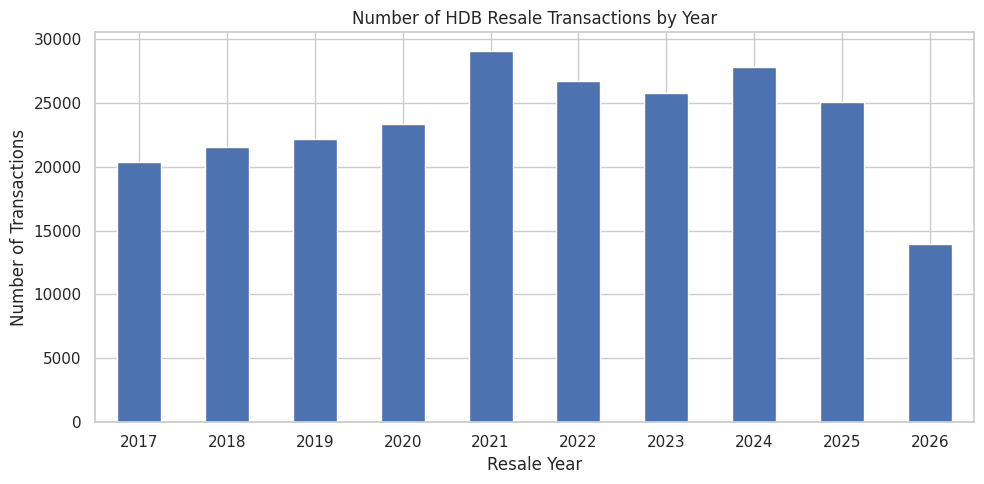

Business insight: Transaction volume indicates market activity. The final year may contain partial-year data and should not be compared directly with complete years.


In [13]:
yearly_volume = df.groupby("resale_year").size()

plt.figure(figsize=(10, 5))
yearly_volume.plot(kind="bar")
plt.title("Number of HDB Resale Transactions by Year")
plt.xlabel("Resale Year")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Business insight: Transaction volume indicates market activity. "
      "The final year may contain partial-year data and should not be compared directly with complete years.")

## 13. Distribution of Resale Prices

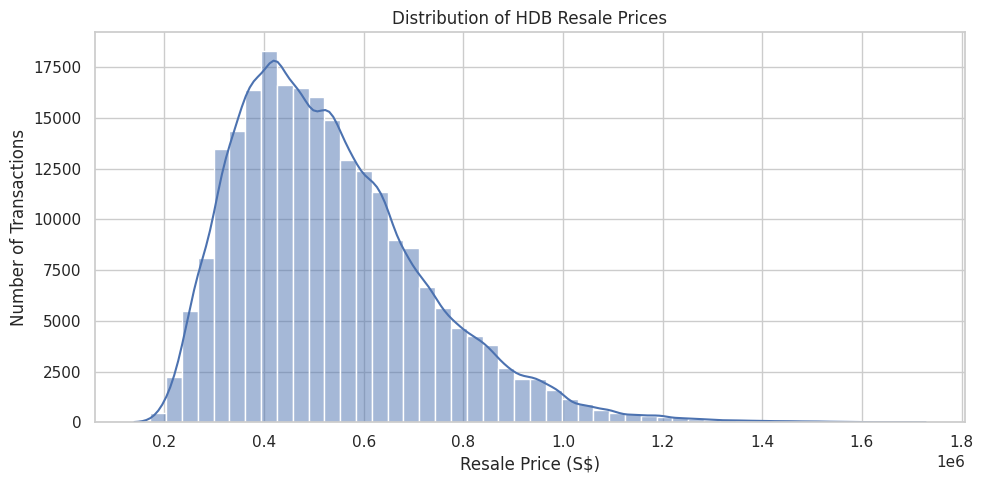

Business insight: The distribution is typically right-skewed because a smaller group of large, central or premium flats transact at substantially higher prices.


In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df["resale_price"], bins=50, kde=True)
plt.title("Distribution of HDB Resale Prices")
plt.xlabel("Resale Price (S$)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

print("Business insight: The distribution is typically right-skewed because a smaller group of large, "
      "central or premium flats transact at substantially higher prices.")

## 14. Average Resale Price by Town

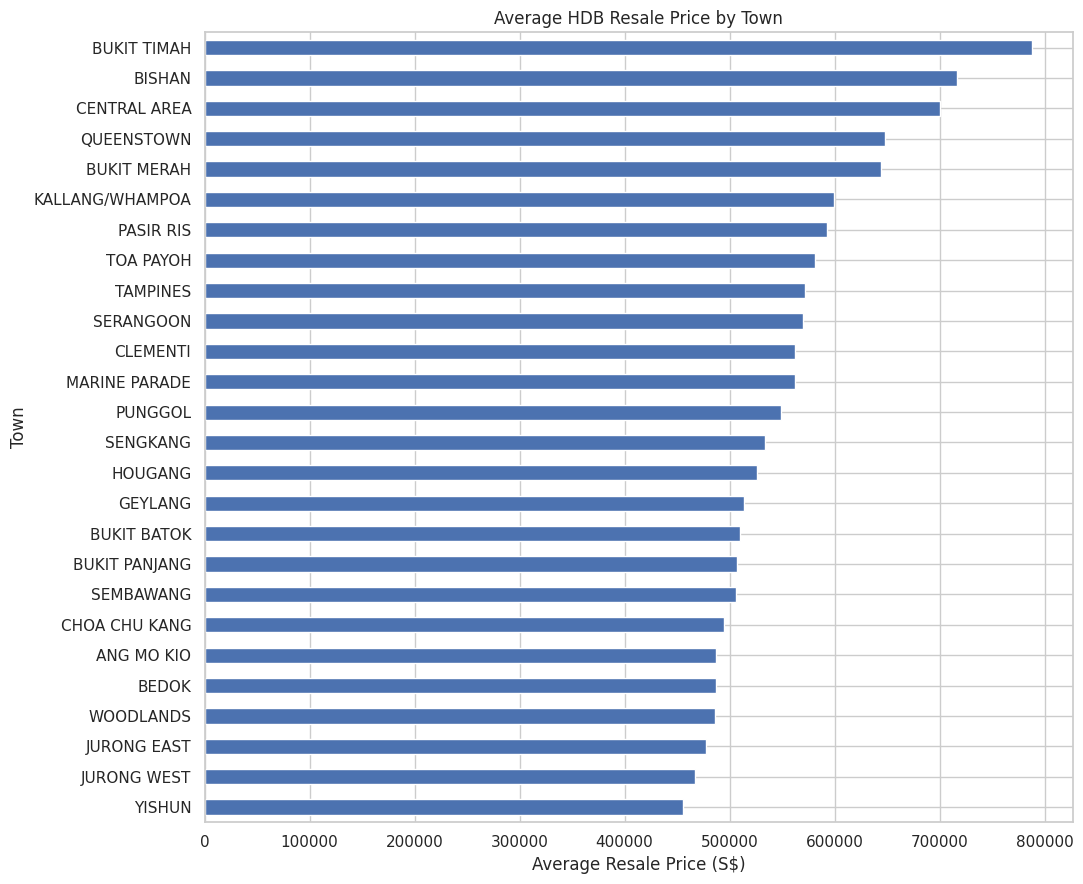

Business insight: Town is an important location variable. Higher-priced towns may reflect centrality, amenities, transport access, maturity and differences in the mix of flat types.


In [15]:
town_price = (
    df.groupby("town")["resale_price"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 9))
town_price.plot(kind="barh")
plt.title("Average HDB Resale Price by Town")
plt.xlabel("Average Resale Price (S$)")
plt.ylabel("Town")
plt.tight_layout()
plt.show()

print("Business insight: Town is an important location variable. Higher-priced towns may reflect centrality, "
      "amenities, transport access, maturity and differences in the mix of flat types.")

## 15. Top 10 Most Expensive Towns

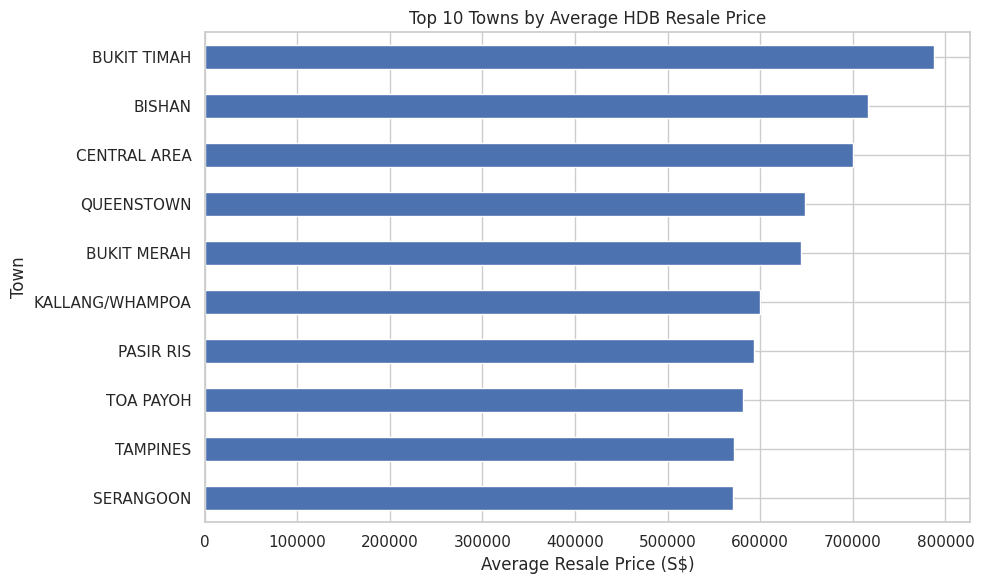

,average_resale_price
town,
BUKIT TIMAH,"787,623.63"
BISHAN,"716,229.82"
CENTRAL AREA,"699,952.06"
QUEENSTOWN,"648,435.23"
BUKIT MERAH,"644,143.64"
KALLANG/WHAMPOA,"599,420.79"
PASIR RIS,"592,936.41"
TOA PAYOH,"581,617.49"
TAMPINES,"571,427.66"


In [16]:
top10_towns = (
    df.groupby("town")["resale_price"]
    .mean()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
top10_towns.plot(kind="barh")
plt.title("Top 10 Towns by Average HDB Resale Price")
plt.xlabel("Average Resale Price (S$)")
plt.ylabel("Town")
plt.tight_layout()
plt.show()

display(top10_towns.sort_values(ascending=False).to_frame("average_resale_price"))

## 16. Average Resale Price by Flat Type

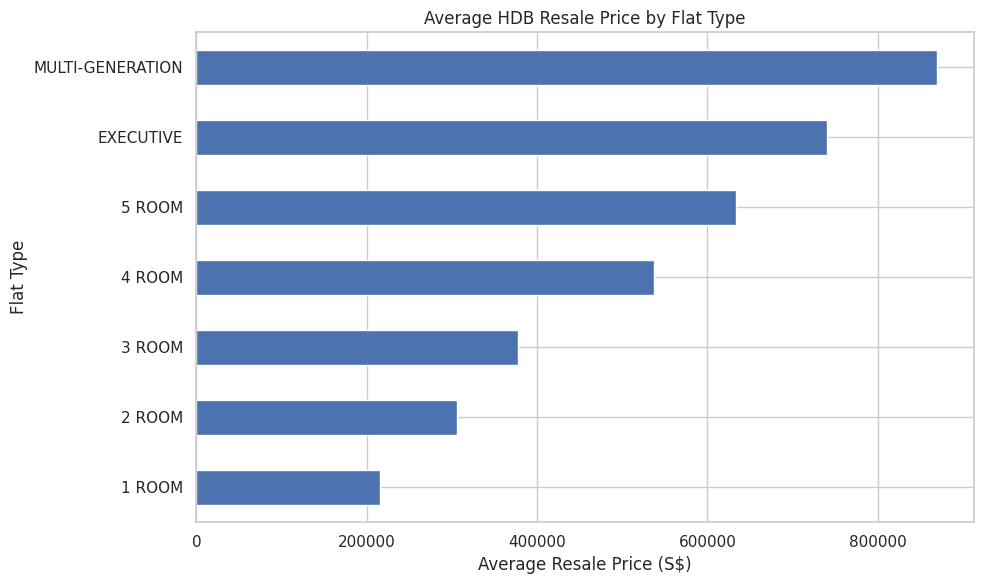

Business insight: Larger flat types generally command higher absolute prices. Flat type should therefore be included as a categorical predictor.


In [17]:
flat_type_price = (
    df.groupby("flat_type")["resale_price"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
flat_type_price.plot(kind="barh")
plt.title("Average HDB Resale Price by Flat Type")
plt.xlabel("Average Resale Price (S$)")
plt.ylabel("Flat Type")
plt.tight_layout()
plt.show()

print("Business insight: Larger flat types generally command higher absolute prices. "
      "Flat type should therefore be included as a categorical predictor.")

## 17. Yearly Resale Price Trend

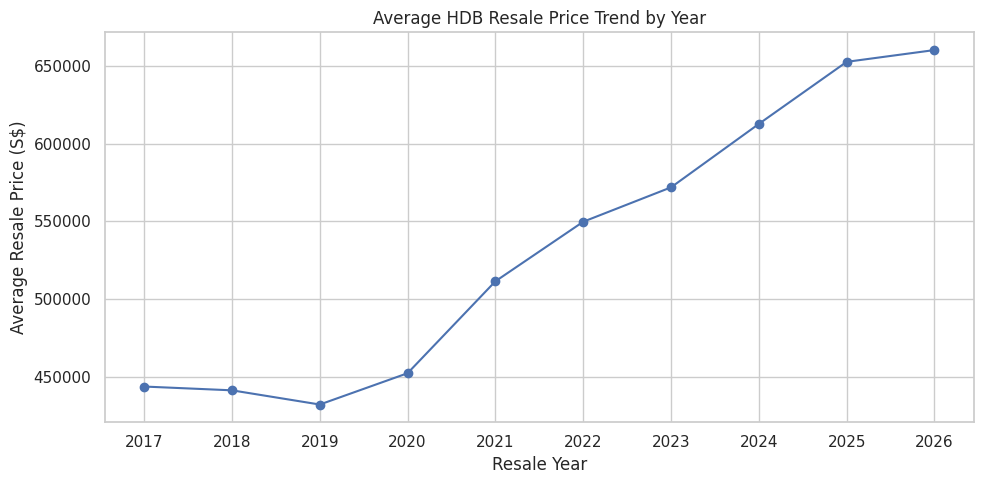

,average_resale_price
resale_year,
2017,"443,743.44"
2018,"441,310.44"
2019,"432,180.07"
2020,"452,312.74"
2021,"511,417.39"
2022,"549,701.07"
2023,"571,814.76"
2024,"612,597.98"
2025,"652,509.23"


Business insight: The time trend captures market-wide changes and supports including resale year or a continuous transaction-date feature in the predictive model.


In [18]:
yearly_price = df.groupby("resale_year")["resale_price"].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_price.index, yearly_price.values, marker="o")
plt.title("Average HDB Resale Price Trend by Year")
plt.xlabel("Resale Year")
plt.ylabel("Average Resale Price (S$)")
plt.xticks(yearly_price.index)
plt.tight_layout()
plt.show()

display(yearly_price.to_frame("average_resale_price"))

print("Business insight: The time trend captures market-wide changes and supports including resale year "
      "or a continuous transaction-date feature in the predictive model.")


## 18. Monthly Resale Price Trend

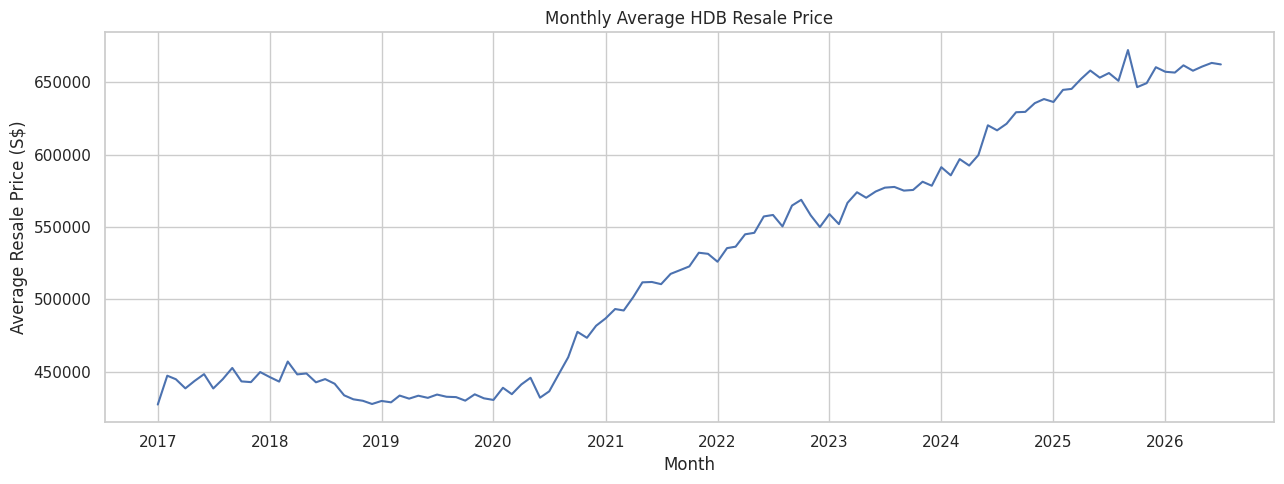

Business insight: Monthly data provides a more detailed view of market movement than annual averages and may reveal short-term changes or seasonality.


In [19]:
monthly_price = df.groupby("month")["resale_price"].mean()

plt.figure(figsize=(13, 5))
plt.plot(monthly_price.index, monthly_price.values)
plt.title("Monthly Average HDB Resale Price")
plt.xlabel("Month")
plt.ylabel("Average Resale Price (S$)")
plt.tight_layout()
plt.show()

print("Business insight: Monthly data provides a more detailed view of market movement than annual averages "
      "and may reveal short-term changes or seasonality.")

## 19. Resale Price by Flat Type — Boxplot

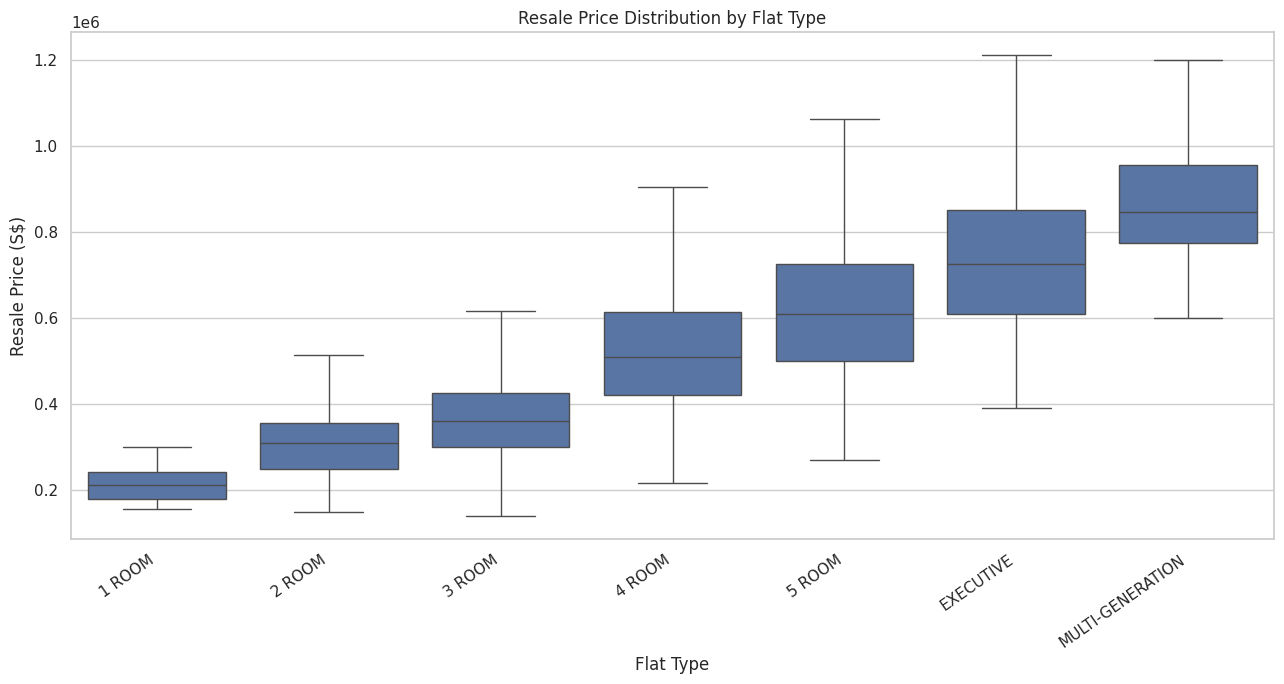

Business insight: The boxplot compares medians and price variability. Substantial overlap shows that location, age, floor area and storey also influence price.


In [20]:
order = df.groupby("flat_type")["resale_price"].median().sort_values().index

plt.figure(figsize=(13, 7))
sns.boxplot(data=df, x="flat_type", y="resale_price", order=order, showfliers=False)
plt.title("Resale Price Distribution by Flat Type")
plt.xlabel("Flat Type")
plt.ylabel("Resale Price (S$)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print("Business insight: The boxplot compares medians and price variability. "
      "Substantial overlap shows that location, age, floor area and storey also influence price.")

## 20. Floor Area versus Resale Price

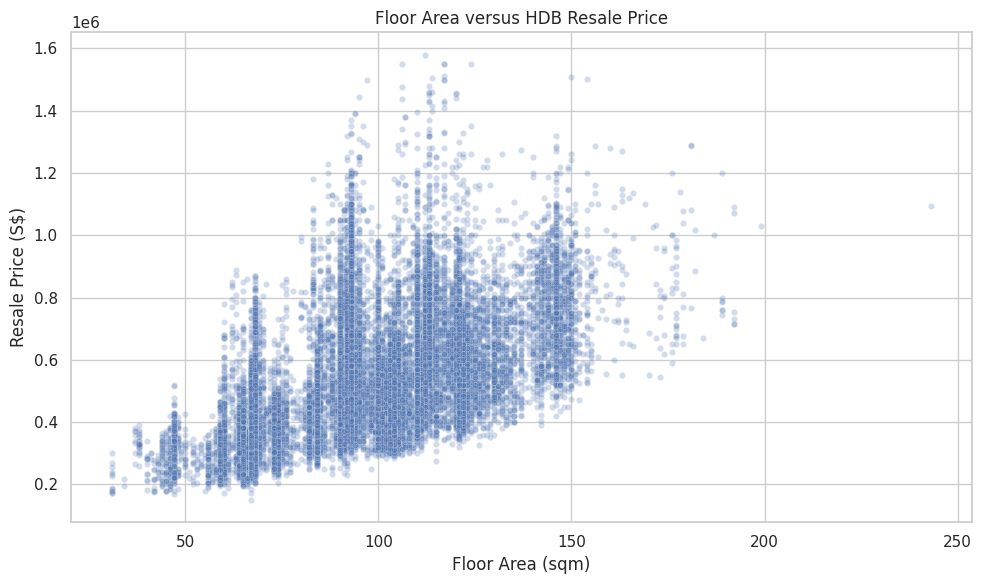

Pearson correlation: 0.565
Business insight: A positive relationship is expected, but the spread confirms that floor area alone cannot explain price differences.


In [21]:
sample = df.sample(min(25000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample,
    x="floor_area_sqm",
    y="resale_price",
    alpha=0.25,
    s=20
)
plt.title("Floor Area versus HDB Resale Price")
plt.xlabel("Floor Area (sqm)")
plt.ylabel("Resale Price (S$)")
plt.tight_layout()
plt.show()

correlation = df["floor_area_sqm"].corr(df["resale_price"])
print(f"Pearson correlation: {correlation:.3f}")
print("Business insight: A positive relationship is expected, but the spread confirms that floor area alone "
      "cannot explain price differences.")

## 21. Remaining Lease and Flat Age Distributions

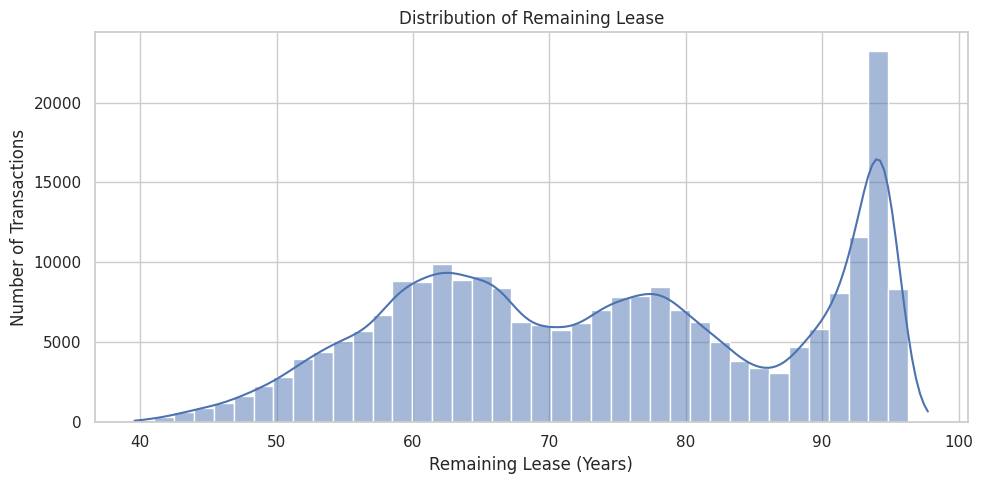

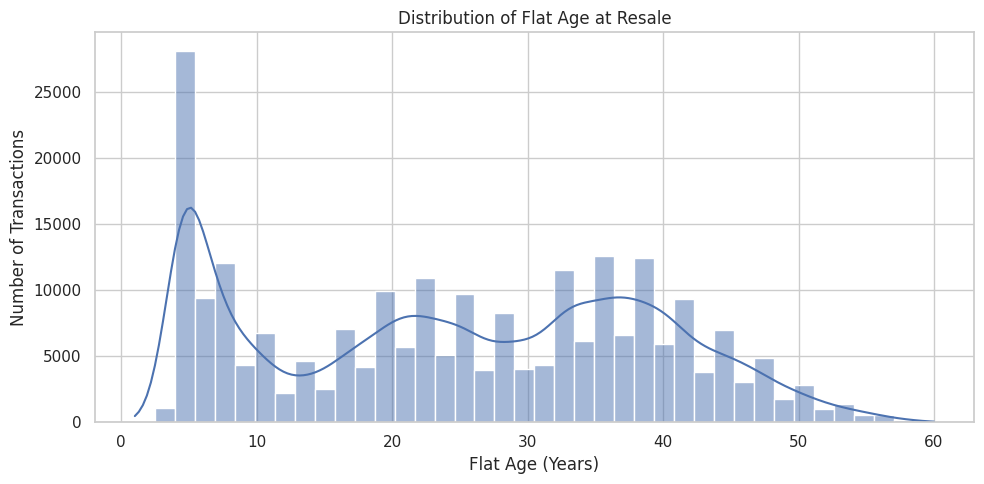

Business insight: Remaining lease and flat age measure related depreciation effects. They should not necessarily be used together in a simple linear model without checking multicollinearity.


In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df["remaining_lease_years"], bins=40, kde=True)
plt.title("Distribution of Remaining Lease")
plt.xlabel("Remaining Lease (Years)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df["flat_age_at_resale"], bins=40, kde=True)
plt.title("Distribution of Flat Age at Resale")
plt.xlabel("Flat Age (Years)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

print("Business insight: Remaining lease and flat age measure related depreciation effects. "
      "They should not necessarily be used together in a simple linear model without checking multicollinearity.")

## 22. Storey Level versus Average Resale Price

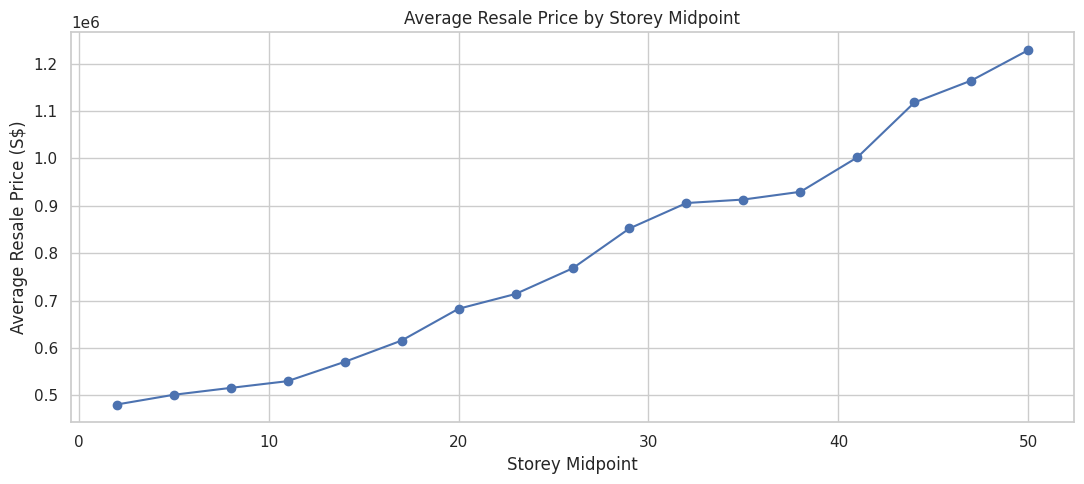

Business insight: Higher-floor units may receive a price premium due to views, ventilation and privacy, although the relationship may also reflect differences in town and flat type.


In [23]:
storey_price = df.groupby("storey_mid")["resale_price"].mean()

plt.figure(figsize=(11, 5))
plt.plot(storey_price.index, storey_price.values, marker="o")
plt.title("Average Resale Price by Storey Midpoint")
plt.xlabel("Storey Midpoint")
plt.ylabel("Average Resale Price (S$)")
plt.tight_layout()
plt.show()

print("Business insight: Higher-floor units may receive a price premium due to views, ventilation and privacy, "
      "although the relationship may also reflect differences in town and flat type.")

## 23. Correlation Heatmap

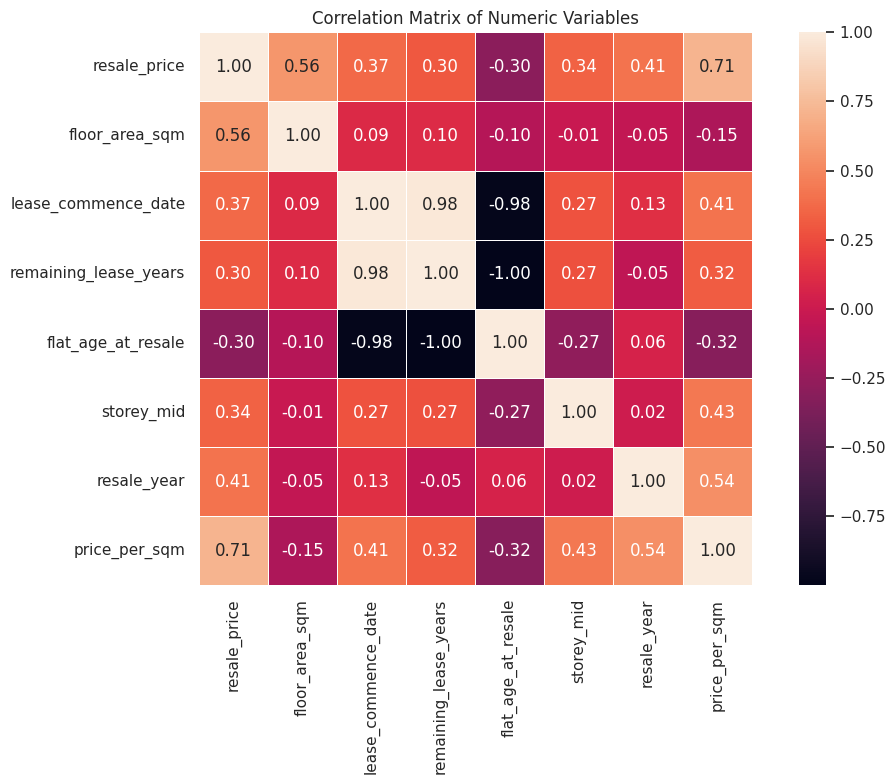

,correlation_with_resale_price
price_per_sqm,0.71
floor_area_sqm,0.56
resale_year,0.41
lease_commence_date,0.37
storey_mid,0.34
remaining_lease_years,0.30
flat_age_at_resale,-0.30


Business insight: Correlation identifies linear associations, not causation. Categorical variables such as town, flat type and flat model require encoding before modelling.


In [24]:
numeric_features = [
    "resale_price",
    "floor_area_sqm",
    "lease_commence_date",
    "remaining_lease_years",
    "flat_age_at_resale",
    "storey_mid",
    "resale_year",
    "price_per_sqm"
]

corr = df[numeric_features].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

display(
    corr["resale_price"]
    .drop("resale_price")
    .sort_values(ascending=False)
    .to_frame("correlation_with_resale_price")
)

print("Business insight: Correlation identifies linear associations, not causation. "
      "Categorical variables such as town, flat type and flat model require encoding before modelling.")

## 24. Recommended Correlation Matrix for Feature Selection

The first correlation matrix provides a broad view of all numeric variables. However, some variables should not be used together when selecting predictors for regression:

- `price_per_sqm` is calculated using `resale_price`, so including it would cause **target leakage**.
- `lease_commence_date`, `remaining_lease_years`, and `flat_age_at_resale` describe closely related lease-age information.
- Their very high absolute correlations indicate **multicollinearity**, which can make linear-regression coefficients unstable and difficult to interpret.

For a cleaner feature-selection matrix, the following variables are retained:

| Variable | Purpose |
|---|---|
| `resale_price` | Target variable |
| `floor_area_sqm` | Physical size of the flat |
| `remaining_lease_years` | Remaining lease value |
| `storey_mid` | Numeric representation of floor level |
| `resale_year` | Market trend over time |

`remaining_lease_years` is selected instead of `lease_commence_date` and `flat_age_at_resale` because it has a direct and understandable relationship with the remaining economic life of the property.

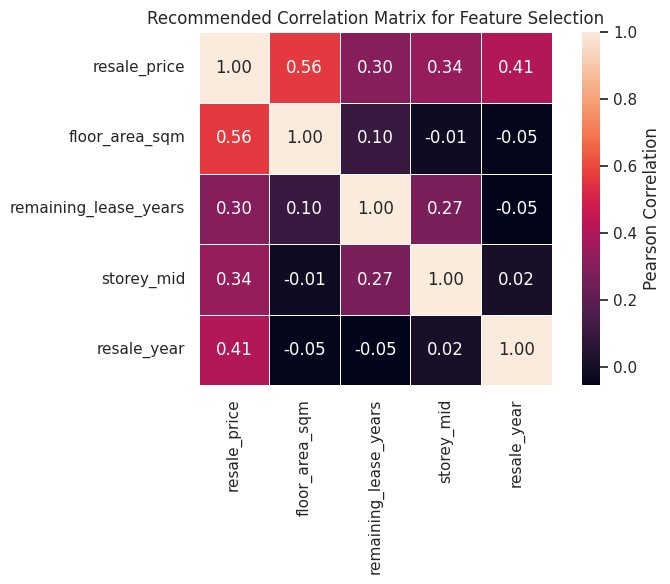

,correlation_with_resale_price
floor_area_sqm,0.56
resale_year,0.41
storey_mid,0.34
remaining_lease_years,0.30


In [25]:
recommended_corr_features = [
    "resale_price",
    "floor_area_sqm",
    "remaining_lease_years",
    "storey_mid",
    "resale_year"
]

recommended_corr = df[recommended_corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    recommended_corr,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"}
)
plt.title("Recommended Correlation Matrix for Feature Selection")
plt.tight_layout()
plt.show()

display(
    recommended_corr["resale_price"]
    .drop("resale_price")
    .sort_values(ascending=False)
    .to_frame("correlation_with_resale_price")
)


### Interpretation of the Recommended Correlation Matrix

#### Floor area (`floor_area_sqm`)

Floor area has the strongest positive relationship with resale price among the selected independent variables. This indicates that larger flats generally command higher prices. The relationship is not perfect because price is also influenced by town, flat type, lease, floor level and market conditions.

**Decision:** Retain for modelling.

#### Resale year (`resale_year`)

A positive correlation with resale price indicates that prices generally increased over the study period. This variable helps the model capture broad market appreciation, inflation, demand changes and other time-related effects.

**Decision:** Retain for modelling.

#### Storey midpoint (`storey_mid`)

The positive relationship suggests that higher-floor units tend to receive a price premium. Possible reasons include better views, privacy, ventilation and lower road noise. The relationship remains moderate because floor level is only one part of the overall pricing decision.

**Decision:** Retain for modelling.

#### Remaining lease (`remaining_lease_years`)

The positive correlation indicates that flats with longer remaining leases generally achieve higher resale prices. A longer lease provides the buyer with a longer period of ownership and may improve financing and future resale attractiveness.

**Decision:** Retain for modelling.

### Variables excluded from the recommended matrix

- **`price_per_sqm`** was excluded because it is derived from `resale_price / floor_area_sqm`. Using it to predict resale price would introduce target leakage.
- **`lease_commence_date`** was excluded because it overlaps strongly with remaining lease and flat age.
- **`flat_age_at_resale`** was excluded because it is almost perfectly negatively correlated with remaining lease.

Keeping only one lease-age measure reduces multicollinearity and creates a more interpretable set of predictors.

### Modelling implication

This matrix is suitable for initial numeric feature selection. Categorical predictors such as `town`, `flat_type` and `flat_model` do not appear in a Pearson correlation matrix, but they should still be encoded and evaluated during Task 4 because they may strongly influence resale price.

## 25. Modelling-Ready Feature Selection

In [26]:
target = "resale_price"

candidate_features = [
    "town",
    "flat_type",
    "storey_mid",
    "floor_area_sqm",
    "flat_model",
    "lease_commence_date",
    "remaining_lease_years",
    "resale_year",
    "resale_month",
    "resale_quarter"
]

print("Target variable:", target)
print("Candidate predictor variables:")
for feature in candidate_features:
    print("-", feature)

print("\nNote: block, street_name and the raw remaining_lease text may be excluded from the initial model "
      "to reduce high-cardinality and redundant information. They can be tested in advanced models.")

Target variable: resale_price
Candidate predictor variables:
- town
- flat_type
- storey_mid
- floor_area_sqm
- flat_model
- lease_commence_date
- remaining_lease_years
- resale_year
- resale_month
- resale_quarter

Note: block, street_name and the raw remaining_lease text may be excluded from the initial model to reduce high-cardinality and redundant information. They can be tested in advanced models.


## 26. Export the Cleaned Dataset

In [27]:
OUTPUT_PATH = Path("HDB_Resale_Cleaned.csv")
df.to_csv(OUTPUT_PATH, index=False)

print(f"Cleaned dataset saved to: {OUTPUT_PATH.resolve()}")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Cleaned dataset saved to: /content/HDB_Resale_Cleaned.csv
Final shape: 235,743 rows × 24 columns


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,remaining_lease_years,resale_year,resale_month,resale_quarter,flat_age_at_resale,storey_low,storey_high,storey_mid,price_per_sqm,resale_price_outlier,floor_area_sqm_outlier,price_per_sqm_outlier,is_any_outlier
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.00,Improved,1979,61 years 04 months,"232,000.00",61.33,2017,1,1,38,10,12,11.00,"5,272.73",False,False,False,False
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.00,New Generation,1978,60 years 07 months,"250,000.00",60.58,2017,1,1,39,1,3,2.00,"3,731.34",False,False,False,False
2,2017-01-01,ANG MO KIO,3 ROOM,118,ANG MO KIO AVE 4,07 TO 09,74.00,New Generation,1978,60 years 04 months,"330,000.00",60.33,2017,1,1,39,7,9,8.00,"4,459.46",False,False,False,False
3,2017-01-01,ANG MO KIO,3 ROOM,119,ANG MO KIO AVE 3,07 TO 09,67.00,New Generation,1978,60 years 10 months,"312,000.00",60.83,2017,1,1,39,7,9,8.00,"4,656.72",False,False,False,False
4,2017-01-01,ANG MO KIO,3 ROOM,150,ANG MO KIO AVE 5,01 TO 03,68.00,New Generation,1981,63 years,"275,000.00",63.00,2017,1,1,36,1,3,2.00,"4,044.12",False,False,False,False


In [28]:
# ============================
# EDA Findings Summary
# ============================

eda_summary = pd.DataFrame({
    "EDA Category": [
        "Dataset Size",
        "Missing Values",
        "Duplicate Records",
        "Target Distribution",
        "Floor Area",
        "Remaining Lease",
        "Flat Age",
        "Storey Midpoint",
        "Town",
        "Flat Type",
        "Correlation Analysis",
        "Outliers"
    ],

    "Key Finding": [
        f"{df.shape[0]:,} records and {df.shape[1]} variables",
        f"{df.isnull().sum().sum()} missing values detected",
        f"{df.duplicated().sum()} duplicate records",
        "Right-skewed distribution with premium-value outliers",
        "Larger flats generally have higher resale prices",
        "Longer remaining leases are associated with higher prices",
        "Older flats generally have lower resale prices",
        "Higher-floor flats tend to command higher prices",
        "Premium towns show significantly higher average resale prices",
        "Larger flat types have higher average resale prices",
        "Floor area has the strongest positive correlation with resale price",
        "Several premium-price transactions identified"
    ],

    "Business Insight": [
        "Dataset size is sufficient for machine learning.",
        "No imputation required.",
        "Duplicates should be removed before modelling.",
        "Consider log transformation if required.",
        "Floor area is an important pricing factor.",
        "Lease tenure significantly affects property value.",
        "Property depreciation influences pricing.",
        "Floor level contributes to market value.",
        "Location is a major determinant of resale price.",
        "Property size strongly affects pricing.",
        "Retain highly correlated predictors for modelling.",
        "Investigate extreme values before model training."
    ]
})

display(eda_summary)

,EDA Category,Key Finding,Business Insight
0,Dataset Size,"235,743 records and 24 variables",Dataset size is sufficient for machine learning.
1,Missing Values,0 missing values detected,No imputation required.
2,Duplicate Records,0 duplicate records,Duplicates should be removed before modelling.
3,Target Distribution,Right-skewed distribution with premium-value o...,Consider log transformation if required.
4,Floor Area,Larger flats generally have higher resale prices,Floor area is an important pricing factor.
5,Remaining Lease,Longer remaining leases are associated with hi...,Lease tenure significantly affects property va...
6,Flat Age,Older flats generally have lower resale prices,Property depreciation influences pricing.
7,Storey Midpoint,Higher-floor flats tend to command higher prices,Floor level contributes to market value.
8,Town,Premium towns show significantly higher averag...,Location is a major determinant of resale price.
9,Flat Type,Larger flat types have higher average resale p...,Property size strongly affects pricing.


## 27. Optional Interactive EDA Dashboard

The dashboard allows to filter the cleaned dataset by town, flat type and resale year.


In [29]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output, display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("Optional dashboard skipped: install ipywidgets to enable it.")


In [30]:
def dashboard(town, flat_type, year):
    filtered = df.copy()
    if town != "All":
        filtered = filtered[filtered["town"] == town]
    if flat_type != "All":
        filtered = filtered[filtered["flat_type"] == flat_type]
    if year != "All":
        filtered = filtered[filtered["resale_year"] == year]

    if filtered.empty:
        print("No transactions match the selected filters.")
        return

    print(f"Transactions: {len(filtered):,}")
    print(f"Average price: S${filtered['resale_price'].mean():,.0f}")
    print(f"Average floor area: {filtered['floor_area_sqm'].mean():.1f} sqm")
    print(f"Average remaining lease: {filtered['remaining_lease_years'].mean():.1f} years")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    sns.histplot(filtered["resale_price"], bins=40, ax=axes[0, 0])
    axes[0, 0].set_title("Resale Price Distribution")

    town_average = filtered.groupby("town")["resale_price"].mean().nlargest(10)
    town_average.plot(kind="bar", ax=axes[0, 1])
    axes[0, 1].set_title("Top 10 Towns by Average Price")
    axes[0, 1].tick_params(axis="x", rotation=45)

    axes[1, 0].scatter(
        filtered["floor_area_sqm"], filtered["resale_price"], alpha=0.25
    )
    axes[1, 0].set_title("Floor Area versus Resale Price")
    axes[1, 0].set_xlabel("Floor Area (sqm)")
    axes[1, 0].set_ylabel("Resale Price (S$)")

    dashboard_features = [
        "floor_area_sqm", "remaining_lease_years", "flat_age_at_resale",
        "storey_mid", "price_per_sqm", "resale_price",
    ]
    sns.heatmap(
        filtered[dashboard_features].corr(), annot=True, fmt=".2f",
        cmap="coolwarm", ax=axes[1, 1]
    )
    axes[1, 1].set_title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()


In [31]:
if WIDGETS_AVAILABLE:
    town_widget = widgets.Dropdown(
        options=["All"] + sorted(df["town"].dropna().unique().tolist()),
        value="All", description="Town:"
    )
    flat_widget = widgets.Dropdown(
        options=["All"] + sorted(df["flat_type"].dropna().unique().tolist()),
        value="All", description="Flat type:"
    )
    year_widget = widgets.Dropdown(
        options=["All"] + sorted(df["resale_year"].dropna().unique().tolist()),
        value="All", description="Year:"
    )
    controls = widgets.HBox([town_widget, flat_widget, year_widget])
    output = widgets.interactive_output(
        dashboard,
        {"town": town_widget, "flat_type": flat_widget, "year": year_widget},
    )
    display(controls, output)


Output()

# Part C – Modelling and Evaluation

This section develops and compares three regression models, tunes the strongest candidate, evaluates it on a chronologically held-out test set, interprets its errors and feature importance, and relates the results to the business objective.


In [32]:
from pathlib import Path
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42

## 1. Load the cleaned dataset

In [33]:
DATA_CANDIDATES = [
    Path("HDB_Resale_Cleaned.csv"),
    Path("/content/HDB_Resale_Cleaned.csv"),
    Path("/mnt/data/HDB_Resale_Cleaned.csv"),
]

DATA_FILE = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_FILE is None:
    raise FileNotFoundError(
        "HDB_Resale_Cleaned.csv was not found. Run Parts A and B first, "
        "or place the cleaned CSV in the same folder as this notebook."
    )

df = pd.read_csv(DATA_FILE, parse_dates=["month"])

print(f"Dataset: {DATA_FILE}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())


Dataset: HDB_Resale_Cleaned.csv
Shape: 235,743 rows × 24 columns


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,remaining_lease_years,resale_year,resale_month,resale_quarter,flat_age_at_resale,storey_low,storey_high,storey_mid,price_per_sqm,resale_price_outlier,floor_area_sqm_outlier,price_per_sqm_outlier,is_any_outlier
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.000,Improved,1979,61 years 04 months,"232,000.000",61.333,2017,1,1,38,10,12,11.000,"5,272.727",False,False,False,False
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.000,New Generation,1978,60 years 07 months,"250,000.000",60.583,2017,1,1,39,1,3,2.000,"3,731.343",False,False,False,False
2,2017-01-01,ANG MO KIO,3 ROOM,118,ANG MO KIO AVE 4,07 TO 09,74.000,New Generation,1978,60 years 04 months,"330,000.000",60.333,2017,1,1,39,7,9,8.000,"4,459.459",False,False,False,False
3,2017-01-01,ANG MO KIO,3 ROOM,119,ANG MO KIO AVE 3,07 TO 09,67.000,New Generation,1978,60 years 10 months,"312,000.000",60.833,2017,1,1,39,7,9,8.000,"4,656.716",False,False,False,False
4,2017-01-01,ANG MO KIO,3 ROOM,150,ANG MO KIO AVE 5,01 TO 03,68.000,New Generation,1981,63 years,"275,000.000",63.000,2017,1,1,36,1,3,2.000,"4,044.118",False,False,False,False


## 2. Select modelling variables

The selected features retain property type, town, size, age, remaining lease, storey, and transaction-time information.


In [35]:
target = "resale_price"

categorical_features = [
    "town",
    "flat_type",
    "flat_model",
]

numeric_features = [
    "floor_area_sqm",
    "resale_year",
    "resale_month",
    "flat_age_at_resale",
    "remaining_lease_years",
    "storey_mid",
]

features = categorical_features + numeric_features

required_columns = features + [target, "month"]
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

model_df = df[required_columns].dropna(subset=[target, "month"]).copy()
model_df = model_df.sort_values("month").reset_index(drop=True)

print(f"Modelling records: {len(model_df):,}")
display(model_df[features + [target]].describe(include="all").T)

Modelling records: 235,743


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
town,235743,26,SENGKANG,19116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flat_type,235743,7,4 ROOM,100071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flat_model,235743,21,Model A,84819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor_area_sqm,"235,743.000",NaN,NaN,NaN,96.690,24.021,31.000,81.000,93.000,112.000,366.700
resale_year,"235,743.000",NaN,NaN,NaN,"2,021.501",2.688,"2,017.000","2,019.000","2,022.000","2,024.000","2,026.000"
resale_month,"235,743.000",NaN,NaN,NaN,6.460,3.386,1.000,4.000,7.000,9.000,12.000
flat_age_at_resale,"235,743.000",NaN,NaN,NaN,24.931,14.274,1.000,11.000,25.000,37.000,60.000
remaining_lease_years,"235,743.000",NaN,NaN,NaN,74.114,14.304,39.583,62.250,73.833,88.583,97.750
storey_mid,"235,743.000",NaN,NaN,NaN,8.783,5.954,2.000,5.000,8.000,11.000,50.000
resale_price,"235,743.000",NaN,NaN,NaN,"532,568.993","191,061.788","140,000.000","390,000.000","500,000.000","640,000.000","1,728,000.000"


In [36]:
print('Columns in df:')
display(df.columns.tolist())

Columns in df:


['month',
 'town',
 'flat_type',
 'block',
 'street_name',
 'storey_range',
 'floor_area_sqm',
 'flat_model',
 'lease_commence_date',
 'remaining_lease',
 'resale_price',
 'remaining_lease_years',
 'resale_year',
 'resale_month',
 'resale_quarter',
 'flat_age_at_resale',
 'storey_low',
 'storey_high',
 'storey_mid',
 'price_per_sqm',
 'resale_price_outlier',
 'floor_area_sqm_outlier',
 'price_per_sqm_outlier',
 'is_any_outlier']

## 3. Create chronological training, validation, and test sets

- **Training:** 2017–2024
- **Validation:** 2025, used for hyperparameter selection
- **Final test:** 2026, used only once for final evaluation




In [38]:
train_df = model_df[model_df["resale_year"] <= 2024].copy()
validation_df = model_df[model_df["resale_year"] == 2025].copy()
test_df = model_df[model_df["resale_year"] >= 2026].copy()

if validation_df.empty or test_df.empty:
    raise ValueError(
        "The expected 2025 validation or 2026 test records are unavailable."
    )

X_train = train_df[features]
y_train = train_df[target]

X_validation = validation_df[features]
y_validation = validation_df[target]

X_test = test_df[features]
y_test = test_df[target]

split_summary = pd.DataFrame({
    "dataset": ["Training", "Validation", "Final test"],
    "records": [len(train_df), len(validation_df), len(test_df)],
    "start_month": [
        train_df["month"].min(),
        validation_df["month"].min(),
        test_df["month"].min(),
    ],
    "end_month": [
        train_df["month"].max(),
        validation_df["month"].max(),
        test_df["month"].max(),
    ],
})

display(split_summary)

,dataset,records,start_month,end_month
0,Training,196686,2017-01-01,2024-12-01
1,Validation,25072,2025-01-01,2025-12-01
2,Final test,13985,2026-01-01,2026-07-01


## 4. Define preprocessing pipelines

In [39]:
# Linear model: one-hot encode categories and standardise numeric variables.
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=True,
                )),
            ]),
            categorical_features,
        ),
    ]
)

# Tree models: ordinal encoding provides a compact numeric matrix.
# Unknown future categories are represented by -1.
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ordinal", OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                )),
            ]),
            categorical_features,
        ),
    ]
)

## 5. Build and compare multiple regression models

The initial comparison is performed on the 2025 validation set. The test set remains untouched.


In [40]:
models = {
    "Ridge Regression": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("model", Ridge(alpha=1.0)),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=150,
            max_depth=22,
            min_samples_leaf=2,
            max_features=0.8,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Histogram Gradient Boosting": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.08,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )),
    ]),
}


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


validation_results = []
fitted_initial_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    predictions = model.predict(X_validation)
    elapsed = time.time() - start

    scores = regression_metrics(y_validation, predictions)
    scores.update({"Model": name, "Training_seconds": elapsed})
    validation_results.append(scores)
    fitted_initial_models[name] = model

validation_results_df = (
    pd.DataFrame(validation_results)
      .set_index("Model")
      .sort_values("RMSE")
)

display(validation_results_df)

,MAE,RMSE,R2,Training_seconds
Model,,,,
Histogram Gradient Boosting,"50,942.054","69,119.160",0.885,3.570
Random Forest,"51,564.479","73,481.207",0.870,51.379
Ridge Regression,"62,142.200","87,644.037",0.816,0.745


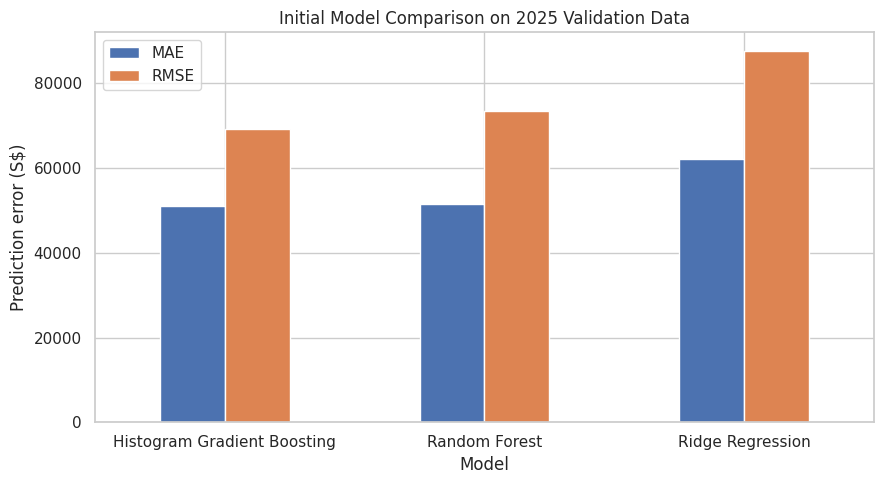

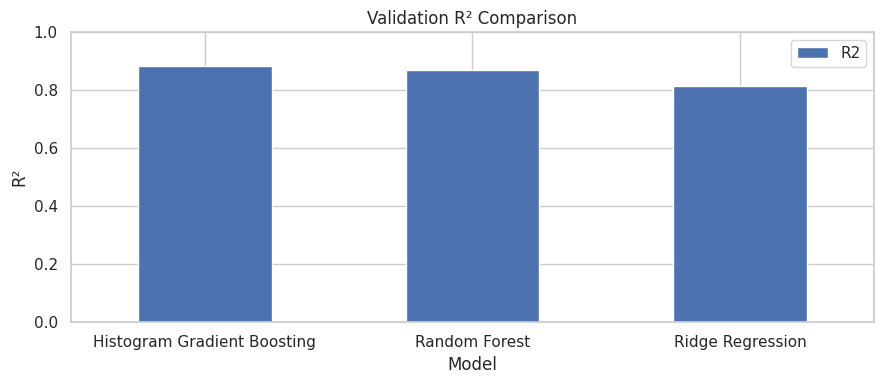

In [41]:
validation_results_df[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(9, 5),
    rot=0,
)
plt.title("Initial Model Comparison on 2025 Validation Data")
plt.ylabel("Prediction error (S$)")
plt.tight_layout()
plt.show()

validation_results_df[["R2"]].plot(
    kind="bar",
    figsize=(9, 4),
    rot=0,
)
plt.title("Validation R² Comparison")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 6. Hyperparameter tuning

Histogram Gradient Boosting is tuned because it generally offers strong predictive performance and efficient training on this dataset. A small, transparent parameter search is performed using the 2025 validation period.

The tuning criterion is **lowest validation RMSE**, because large pricing errors are especially important in property valuation.


In [42]:
parameter_candidates = [
    {
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 0.0,
    },
    {
        "learning_rate": 0.08,
        "max_iter": 300,
        "max_leaf_nodes": 31,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.05,
        "max_iter": 450,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
    },
    {
        "learning_rate": 0.08,
        "max_iter": 350,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 20,
        "l2_regularization": 2.0,
    },
    {
        "learning_rate": 0.06,
        "max_iter": 400,
        "max_leaf_nodes": 63,
        "min_samples_leaf": 30,
        "l2_regularization": 5.0,
    },
    {
        "learning_rate": 0.04,
        "max_iter": 500,
        "max_leaf_nodes": 127,
        "min_samples_leaf": 30,
        "l2_regularization": 5.0,
    },
]

tuning_results = []
tuned_models = []

for candidate_number, params in enumerate(parameter_candidates, start=1):
    candidate_model = Pipeline([
        ("preprocessor", clone(tree_preprocessor)),
        ("model", HistGradientBoostingRegressor(
            random_state=RANDOM_STATE,
            **params,
        )),
    ])

    start = time.time()
    candidate_model.fit(X_train, y_train)
    validation_prediction = candidate_model.predict(X_validation)
    elapsed = time.time() - start

    scores = regression_metrics(y_validation, validation_prediction)
    tuning_results.append({
        "Candidate": candidate_number,
        **params,
        **scores,
        "Training_seconds": elapsed,
    })
    tuned_models.append(candidate_model)

tuning_results_df = (
    pd.DataFrame(tuning_results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

display(tuning_results_df)

,Candidate,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,MAE,RMSE,R2,Training_seconds
0,6,0.040,500,127,30,5.000,"49,004.352","65,461.763",0.897,10.553
1,4,0.080,350,63,20,2.000,"49,358.710","65,967.033",0.895,4.939
2,3,0.050,450,63,20,1.000,"49,463.083","66,317.508",0.894,6.658
3,5,0.060,400,63,30,5.000,"49,824.731","67,052.243",0.892,5.770
4,2,0.080,300,31,20,1.000,"50,942.054","69,119.160",0.885,3.466
5,1,0.050,300,31,20,0.000,"52,271.488","72,412.453",0.874,4.353


In [43]:
best_candidate_number = int(tuning_results_df.loc[0, "Candidate"])
best_parameters = parameter_candidates[best_candidate_number - 1]

print("Selected parameters:")
print(best_parameters)
print(
    f"Best validation RMSE: "
    f"S${tuning_results_df.loc[0, 'RMSE']:,.2f}"
)

Selected parameters:
{'learning_rate': 0.04, 'max_iter': 500, 'max_leaf_nodes': 127, 'min_samples_leaf': 30, 'l2_regularization': 5.0}
Best validation RMSE: S$65,461.76


## 7. Refit the selected model and evaluate on the final test set

After selecting the best hyperparameters, the model is retrained using all data from 2017–2025. It is then evaluated once on the untouched 2026 test set.


In [44]:
development_df = model_df[model_df["resale_year"] <= 2025].copy()

X_development = development_df[features]
y_development = development_df[target]

final_model = Pipeline([
    ("preprocessor", clone(tree_preprocessor)),
    ("model", HistGradientBoostingRegressor(
        random_state=RANDOM_STATE,
        **best_parameters,
    )),
])

start = time.time()
final_model.fit(X_development, y_development)
final_predictions = final_model.predict(X_test)
final_training_seconds = time.time() - start

final_metrics = regression_metrics(y_test, final_predictions)
final_metrics["Training_seconds"] = final_training_seconds

final_metrics_df = pd.DataFrame(
    final_metrics,
    index=["Tuned Histogram Gradient Boosting"],
)

display(final_metrics_df)

,MAE,RMSE,R2,Training_seconds
Tuned Histogram Gradient Boosting,"37,274.689","53,549.332",0.937,10.730


### Interpretation

- An MAE of S\$40,000 means the model's prediction differs from the actual resale price by approximately S\$40,000 on average.
- RMSE is normally higher than MAE because it penalises large errors more heavily.
- An R² of 0.93 means the model explains approximately 93% of the variation in the final test-set resale prices.

The exact values are generated from the uploaded cleaned dataset when the notebook is run.


## 8. Examine prediction errors

In [45]:
prediction_results = test_df[
    ["month", "town", "flat_type", "floor_area_sqm", "resale_price"]
].copy()

prediction_results["predicted_resale_price"] = final_predictions
prediction_results["residual"] = (
    prediction_results["resale_price"]
    - prediction_results["predicted_resale_price"]
)
prediction_results["absolute_error"] = prediction_results["residual"].abs()
prediction_results["absolute_percentage_error"] = (
    prediction_results["absolute_error"]
    / prediction_results["resale_price"]
    * 100
)

display(prediction_results.head())
display(
    prediction_results[
        ["residual", "absolute_error", "absolute_percentage_error"]
    ].describe().T
)

,month,town,flat_type,floor_area_sqm,resale_price,predicted_resale_price,residual,absolute_error,absolute_percentage_error
221758,2026-01-01,SENGKANG,4 ROOM,92.000,"785,000.000","752,737.179","32,262.821","32,262.821",4.110
221759,2026-01-01,SENGKANG,4 ROOM,85.000,"570,000.000","563,477.517","6,522.483","6,522.483",1.144
221760,2026-01-01,SENGKANG,4 ROOM,102.000,"600,000.000","578,553.093","21,446.907","21,446.907",3.574
221761,2026-01-01,SENGKANG,4 ROOM,92.000,"575,000.000","562,830.207","12,169.793","12,169.793",2.116
221762,2026-01-01,SENGKANG,4 ROOM,97.000,"706,000.000","704,638.423","1,361.577","1,361.577",0.193


,count,mean,std,min,25%,50%,75%,max
residual,"13,985.000","5,851.414","53,230.579","-301,091.749","-24,595.431",-163.640,"28,265.803","656,538.416"
absolute_error,"13,985.000","37,274.689","38,447.811",3.014,"11,709.123","26,198.667","49,311.174","656,538.416"
absolute_percentage_error,"13,985.000",5.520,4.802,0.000,1.957,4.348,7.808,113.620


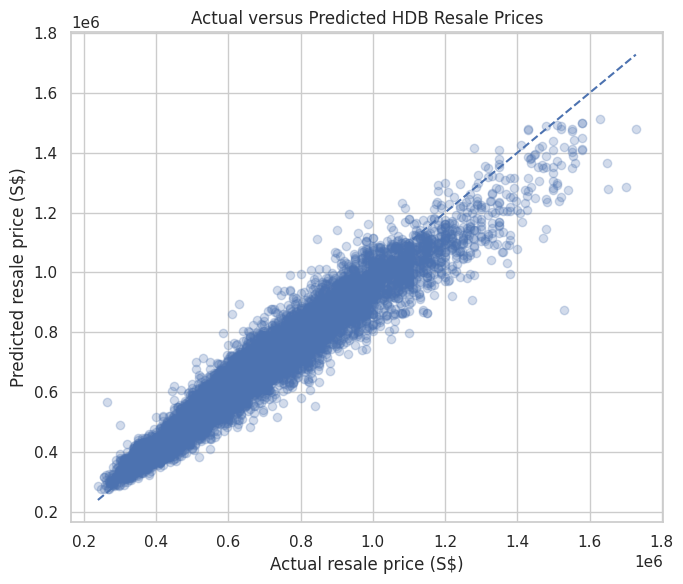

In [46]:
plt.figure(figsize=(7, 6))
plt.scatter(
    prediction_results["resale_price"],
    prediction_results["predicted_resale_price"],
    alpha=0.25,
)
minimum = min(
    prediction_results["resale_price"].min(),
    prediction_results["predicted_resale_price"].min(),
)
maximum = max(
    prediction_results["resale_price"].max(),
    prediction_results["predicted_resale_price"].max(),
)
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.title("Actual versus Predicted HDB Resale Prices")
plt.xlabel("Actual resale price (S$)")
plt.ylabel("Predicted resale price (S$)")
plt.tight_layout()
plt.show()

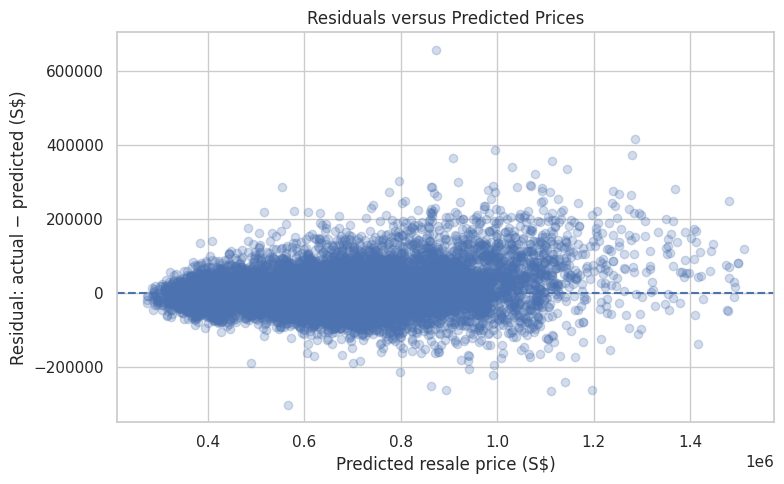

In [47]:
plt.figure(figsize=(8, 5))
plt.scatter(
    prediction_results["predicted_resale_price"],
    prediction_results["residual"],
    alpha=0.25,
)
plt.axhline(0, linestyle="--")
plt.title("Residuals versus Predicted Prices")
plt.xlabel("Predicted resale price (S$)")
plt.ylabel("Residual: actual − predicted (S$)")
plt.tight_layout()
plt.show()

## 9. Segment-level evaluation

Overall metrics can hide weaker performance for particular towns or flat types. Segment-level MAE helps identify where predictions require more caution.


In [48]:
town_performance = (
    prediction_results.groupby("town")
    .agg(
        transactions=("resale_price", "size"),
        actual_mean=("resale_price", "mean"),
        predicted_mean=("predicted_resale_price", "mean"),
        MAE=("absolute_error", "mean"),
        median_APE=("absolute_percentage_error", "median"),
    )
    .sort_values("MAE", ascending=False)
)

flat_type_performance = (
    prediction_results.groupby("flat_type")
    .agg(
        transactions=("resale_price", "size"),
        actual_mean=("resale_price", "mean"),
        predicted_mean=("predicted_resale_price", "mean"),
        MAE=("absolute_error", "mean"),
        median_APE=("absolute_percentage_error", "median"),
    )
    .sort_values("MAE", ascending=False)
)

print("Performance by town:")
display(town_performance)

print("Performance by flat type:")
display(flat_type_performance)

Performance by town:


,transactions,actual_mean,predicted_mean,MAE,median_APE
town,,,,,
CENTRAL AREA,97,"890,574.928","855,185.216","73,060.515",6.789
BUKIT MERAH,535,"768,889.656","750,191.165","65,666.635",6.875
BUKIT TIMAH,34,"998,143.765","962,059.837","64,437.076",5.739
KALLANG/WHAMPOA,399,"740,480.589","709,655.234","60,818.106",6.995
SERANGOON,201,"703,826.050","687,561.726","59,543.231",7.030
TOA PAYOH,527,"745,917.884","724,063.385","56,140.183",7.089
QUEENSTOWN,450,"810,313.647","782,669.064","54,044.188",5.785
BISHAN,222,"847,121.320","844,137.698","53,043.508",5.166
CLEMENTI,289,"716,949.456","692,999.565","51,171.492",6.173


Performance by flat type:


,transactions,actual_mean,predicted_mean,MAE,median_APE
flat_type,,,,,
MULTI-GENERATION,4,"1,136,250.000","1,071,921.650","64,328.350",4.544
EXECUTIVE,846,"925,050.897","918,802.744","50,526.228",4.257
5 ROOM,3232,"789,647.144","781,423.123","48,054.439",4.599
4 ROOM,6157,"676,744.900","671,039.128","36,683.300",4.194
3 ROOM,3309,"472,364.412","469,168.380","26,700.430",4.427
1 ROOM,7,"260,269.714","285,147.518","24,877.804",8.474
2 ROOM,430,"373,112.409","363,398.974","19,970.079",3.976


## 10. Feature importance using permutation importance

Permutation importance measures how much test-set prediction performance deteriorates when one feature is randomly shuffled. Larger values indicate greater predictive importance.

A sample is used to keep computation efficient.


In [49]:
importance_sample_size = min(5_000, len(X_test))
importance_sample = X_test.sample(
    n=importance_sample_size,
    random_state=RANDOM_STATE,
)
importance_target = y_test.loc[importance_sample.index]

importance_result = permutation_importance(
    final_model,
    importance_sample,
    importance_target,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

feature_importance_df = (
    pd.DataFrame({
        "feature": features,
        "importance_mean": importance_result.importances_mean,
        "importance_std": importance_result.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)

display(feature_importance_df)

,feature,importance_mean,importance_std
3,floor_area_sqm,"110,500.556","1,602.202"
0,town,"99,571.850","1,560.840"
1,flat_type,"44,133.200",526.519
7,remaining_lease_years,"40,882.390",995.378
6,flat_age_at_resale,"30,780.999",875.797
8,storey_mid,"24,672.912",669.325
2,flat_model,"12,029.941",213.117
5,resale_month,39.908,163.074
4,resale_year,0.000,0.000


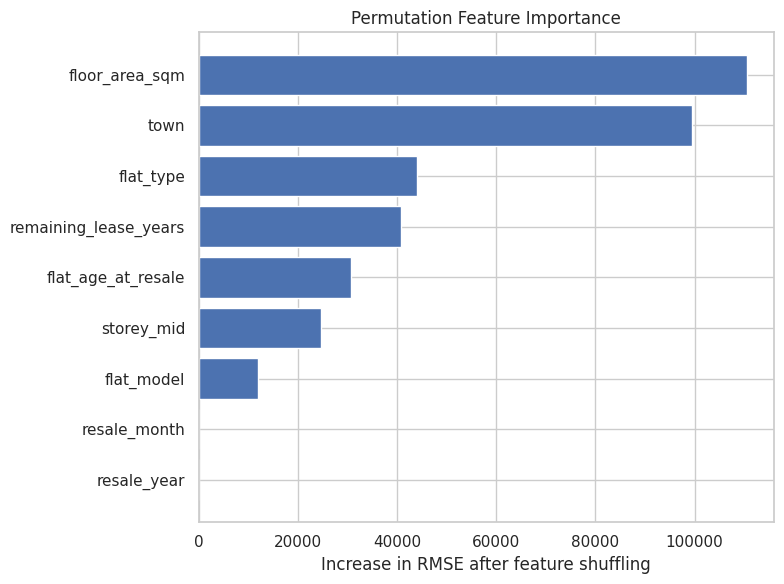

In [50]:
plot_data = feature_importance_df.sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(plot_data["feature"], plot_data["importance_mean"])
plt.title("Permutation Feature Importance")
plt.xlabel("Increase in RMSE after feature shuffling")
plt.tight_layout()
plt.show()

## 11. Business-objective assessment and recommendations

### Assessment

The final model should be considered useful when it:

- substantially outperforms the linear baseline;
- achieves a high R² and acceptably low MAE/RMSE on the future 2026 test period;
- produces stable performance across major towns and flat types;
- provides estimates that support, rather than replace, professional valuation judgement.

### Interpretation

The model captures nonlinear relationships between resale price and factors such as town, floor area, flat type, remaining lease, storey, and market timing. The feature-importance results indicate which attributes contribute most to predictive accuracy.

### Recommendations

1. **Sellers:** Use the predicted price as an evidence-based starting point, then adjust for renovation condition, exact location, view, and current listing competition.
2. **Buyers:** Compare the asking price with the model estimate and review the likely error range before negotiating.
3. **Agency advisers:** Use the model to standardise preliminary valuations and identify cases requiring deeper comparative-market analysis.
4. **Risk control:** Give additional attention to segments with high MAE or low transaction volume.
5. **Model maintenance:** Retrain the model regularly as new transactions become available because market conditions change over time.
6. **Future enhancement:** Add distance to MRT stations, schools, amenities, town-level supply, interest rates, and policy-period indicators where reliable data is available.

The prediction is a decision-support estimate based on historical transaction patterns.


## 12. Save the model, metrics, and predictions

In [51]:
OUTPUT_DIR = Path("task4_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

joblib.dump(final_model, OUTPUT_DIR / "hdb_final_regression_model.joblib")
validation_results_df.to_csv(
    OUTPUT_DIR / "initial_model_comparison.csv"
)
tuning_results_df.to_csv(
    OUTPUT_DIR / "hyperparameter_tuning_results.csv",
    index=False,
)
final_metrics_df.to_csv(
    OUTPUT_DIR / "final_test_metrics.csv"
)
prediction_results.to_csv(
    OUTPUT_DIR / "hdb_2026_test_predictions.csv",
    index=False,
)
town_performance.to_csv(
    OUTPUT_DIR / "performance_by_town.csv"
)
flat_type_performance.to_csv(
    OUTPUT_DIR / "performance_by_flat_type.csv"
)
feature_importance_df.to_csv(
    OUTPUT_DIR / "feature_importance.csv",
    index=False,
)

print("Saved outputs:")
for file_path in sorted(OUTPUT_DIR.iterdir()):
    print(f"- {file_path}")

Saved outputs:
- task4_outputs/feature_importance.csv
- task4_outputs/final_test_metrics.csv
- task4_outputs/hdb_2026_test_predictions.csv
- task4_outputs/hdb_final_regression_model.joblib
- task4_outputs/hyperparameter_tuning_results.csv
- task4_outputs/initial_model_comparison.csv
- task4_outputs/performance_by_flat_type.csv
- task4_outputs/performance_by_town.csv


## 13. Final report paragraph

Three supervised regression algorithms—Ridge Regression, Random Forest, and Histogram Gradient Boosting—were developed and evaluated using a chronological validation design. The models were trained using transactions from 2017 to 2024 and initially compared using 2025 transactions. MAE, RMSE, and R² were selected as the evaluation metrics. Histogram Gradient Boosting was subsequently tuned by varying its learning rate, number of boosting iterations, number of leaf nodes, minimum leaf size, and L2 regularisation. The configuration with the lowest validation RMSE was retrained using all transactions from 2017 to 2025 and evaluated on the untouched 2026 test data. The final model's results, residual analysis, segment-level performance, and feature importance were used to assess its ability to support data-backed pricing recommendations. The model provides a consistent preliminary price estimate, although unusual properties and rapidly changing market conditions should still be reviewed by an experienced property adviser.
